# 1.0 GPU check + install YOLO (Ultralytics)

In [1]:
!nvidia-smi
!pip -q install ultralytics


Tue Feb 17 20:46:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#  2 Dataset Configuration 

## 2.1 Define Dataset Path

In [2]:
# Dataset base path (based on your structure screenshot)
DATASET_BASE = "/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data"

WORK_DIR = "/kaggle/working"

print("Dataset Base:", DATASET_BASE)


Dataset Base: /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data


## 2.2 Verify Folder Structure

This confirms that train/valid/test exist correctly.

In [3]:
import os

required_paths = [
    f"{DATASET_BASE}/train/images",
    f"{DATASET_BASE}/train/labels",
    f"{DATASET_BASE}/valid/images",
    f"{DATASET_BASE}/valid/labels",
    f"{DATASET_BASE}/test/images",
    f"{DATASET_BASE}/test/labels",
]

for path in required_paths:
    print(path, "=>", os.path.exists(path))


/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/train/images => True
/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/train/labels => True
/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/valid/images => True
/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/valid/labels => True
/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images => True
/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/labels => True


## 2.3 Count Images Per Split

In [4]:
import glob

def count_split(split):
    imgs = glob.glob(f"{DATASET_BASE}/{split}/images/*.*")
    lbls = glob.glob(f"{DATASET_BASE}/{split}/labels/*.txt")
    return len(imgs), len(lbls)

for split in ["train", "valid", "test"]:
    imgs, lbls = count_split(split)
    print(f"{split.upper():6s} | Images: {imgs:4d} | Labels: {lbls:4d}")


TRAIN  | Images: 2605 | Labels: 2605
VALID  | Images:  114 | Labels:  114
TEST   | Images:   82 | Labels:   82


## 2.4 Define Class Names

In [5]:
NAMES = [
    "Hardhat","Mask","NO-Hardhat","NO-Mask","NO-Safety Vest",
    "Person","Safety Cone","Safety Vest","machinery","vehicle"
]

print("Number of Classes:", len(NAMES))
print("Classes:", NAMES)


Number of Classes: 10
Classes: ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']


## 2.5 Create data.yaml File (IMPORTANT)

In [6]:
import textwrap

DATA_YAML = f"{WORK_DIR}/data.yaml"

yaml_text = f"""
path: {DATASET_BASE}
train: train/images
val: valid/images
test: test/images
names: {NAMES}
"""

with open(DATA_YAML, "w") as f:
    f.write(textwrap.dedent(yaml_text).strip())

print("data.yaml created at:", DATA_YAML)
print("\n--- YAML CONTENT ---\n")
print(open(DATA_YAML).read())


data.yaml created at: /kaggle/working/data.yaml

--- YAML CONTENT ---

path: /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data
train: train/images
val: valid/images
test: test/images
names: ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']


# STEP 3 — Dataset Analysis (FULL)

## 3.1 Count Total Images & Labels

In [7]:
import glob

total_images = len(glob.glob(f"{DATASET_BASE}/**/images/*.*", recursive=True))
total_labels = len(glob.glob(f"{DATASET_BASE}/**/labels/*.txt", recursive=True))

print("Total Images:", total_images)
print("Total Label Files:", total_labels)


Total Images: 2801
Total Label Files: 2801


## 3.2 Count Bounding Boxes Per Class

In [8]:
from collections import Counter

label_files = glob.glob(f"{DATASET_BASE}/**/labels/*.txt", recursive=True)

class_counts = Counter()
total_boxes = 0

for lf in label_files:
    with open(lf, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cid = int(float(parts[0]))
                class_counts[cid] += 1
                total_boxes += 1

print("Total Bounding Boxes:", total_boxes)
print("\nClass Distribution:\n")

for cid in sorted(class_counts):
    print(f"{cid:2d} {NAMES[cid]:15s} : {class_counts[cid]}")


Total Bounding Boxes: 38352

Class Distribution:

 0 Hardhat         : 3334
 1 Mask            : 1700
 2 NO-Hardhat      : 2427
 3 NO-Mask         : 3250
 4 NO-Safety Vest  : 4158
 5 Person          : 9872
 6 Safety Cone     : 3502
 7 Safety Vest     : 3135
 8 machinery       : 5346
 9 vehicle         : 1628


## 3.3 Visualize Class Distribution

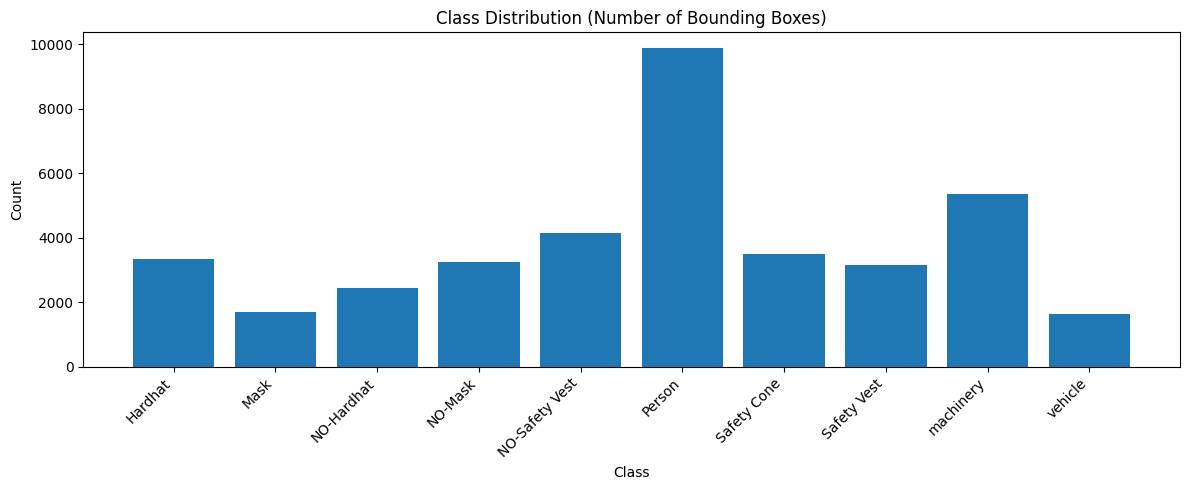

In [9]:
import matplotlib.pyplot as plt

ids = sorted(class_counts)
values = [class_counts[i] for i in ids]
labels = [NAMES[i] for i in ids]

plt.figure(figsize=(12,5))
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution (Number of Bounding Boxes)")
plt.ylabel("Count")
plt.xlabel("Class")
plt.tight_layout()
plt.show()


## 3.4 Check Label Quality (Missing / Empty Labels)

In [10]:
import os

missing = 0
empty = 0

image_files = glob.glob(f"{DATASET_BASE}/**/images/*.*", recursive=True)

for img in image_files:
    lbl = img.replace("/images/", "/labels/")
    lbl = os.path.splitext(lbl)[0] + ".txt"
    
    if not os.path.exists(lbl):
        missing += 1
    elif os.path.getsize(lbl) == 0:
        empty += 1

print("Missing Label Files:", missing)
print("Empty Label Files:", empty)


Missing Label Files: 0
Empty Label Files: 24


## 3.5 Show Sample Images

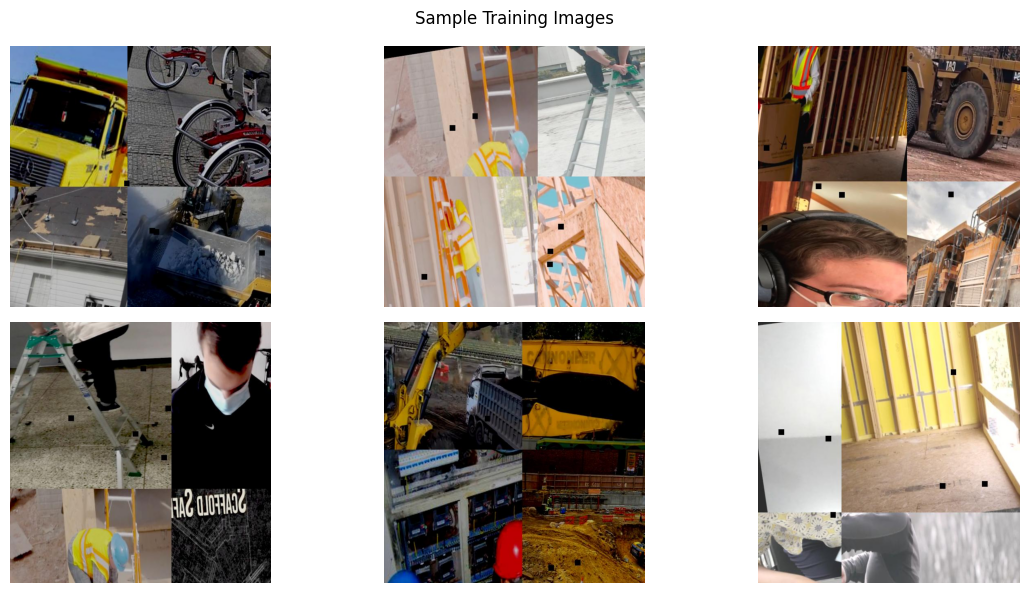

In [11]:
from PIL import Image
import random

sample_images = random.sample(
    glob.glob(f"{DATASET_BASE}/train/images/*.*"),
    6
)

plt.figure(figsize=(12,6))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()


# STEP 4 (Advanced) — Multi-Model Training (YOLO Family Comparison)

## 4.1 Import YOLO

In [12]:
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 4.2 Define Training Settings (Keep Same for Fair Comparison)

In [13]:
EPOCHS = 80
IMGSZ  = 640
BATCH  = 16
SEED   = 42

MODELS = [
    "yolov8n.pt",
    "yolov8s.pt",
    "yolov8m.pt"
]


## 4.3 Train All Models Sequentially

In [14]:
for model_name in MODELS:
    
    print("\n==============================")
    print("Training:", model_name)
    print("==============================\n")
    
    model = YOLO(model_name)
    
    model.train(
        data=DATA_YAML,
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        seed=SEED,
        name=model_name.replace(".pt","")
    )



Training: yolov8n.pt

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

## 4.4 Evaluate Each Model

In [15]:
results_summary = []

for model_name in ["yolov8n", "yolov8s", "yolov8m"]:
    
    print("\nEvaluating:", model_name)
    
    best_path = f"runs/detect/{model_name}/weights/best.pt"
    model = YOLO(best_path)
    
    metrics = model.val(data=DATA_YAML)
    
    results_summary.append({
        "Model": model_name,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr
    })



Evaluating: yolov8n
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 38.2±21.3 MB/s, size: 61.4 KB)
val: Scanning /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/valid/labels... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 406.9it/s 0.3s
WARNING ⚠️ val: Cache directory /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.5it/s 3.2s
                   all        114        697      0.901      0.718      0.798      0.499
               Hardhat         42         79      0.925      0.722      0.852      0.532
                  Mask         19         21          1      0.879       0.94      0.677
            NO-Hardh

## 4.5 Create Academic Comparison Table

In [16]:
import pandas as pd

summary_df = pd.DataFrame(results_summary)
summary_df


,Model,mAP50,mAP50-95,Precision,Recall
0,yolov8n,0.797558,0.499148,0.900857,0.717926
1,yolov8s,0.856966,0.582381,0.950987,0.770974
2,yolov8m,0.876540,0.626240,0.914581,0.818007


## 4.6 Visualize Model Comparison

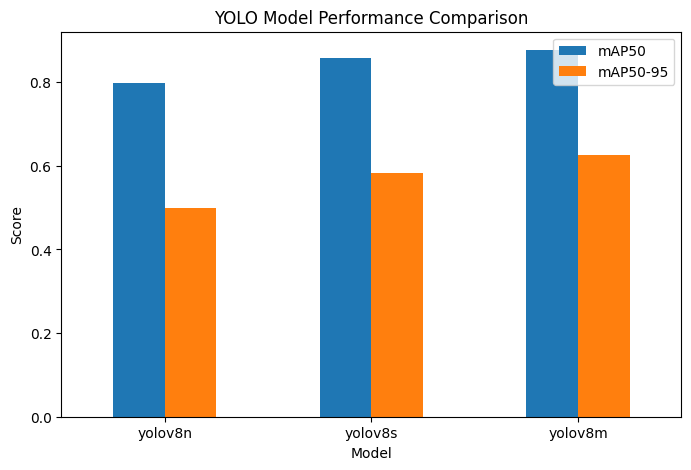

In [17]:
summary_df.set_index("Model")[["mAP50","mAP50-95"]].plot(
    kind="bar",
    figsize=(8,5),
    title="YOLO Model Performance Comparison"
)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


## 4.7 Display Confusion Matrix


Confusion Matrix — yolov8n


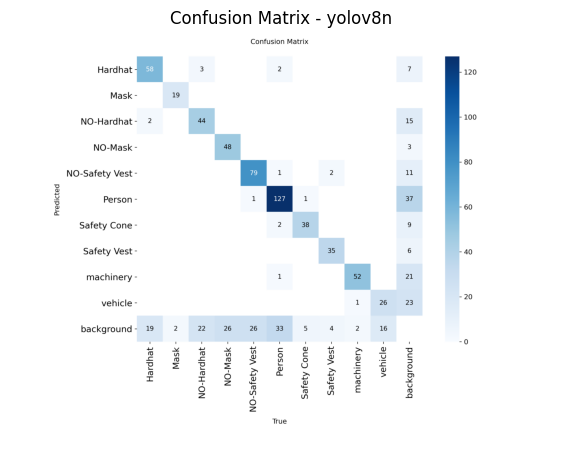


Confusion Matrix — yolov8s


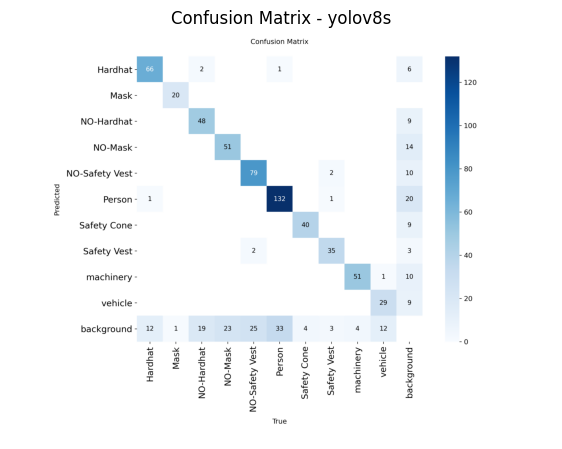


Confusion Matrix — yolov8m


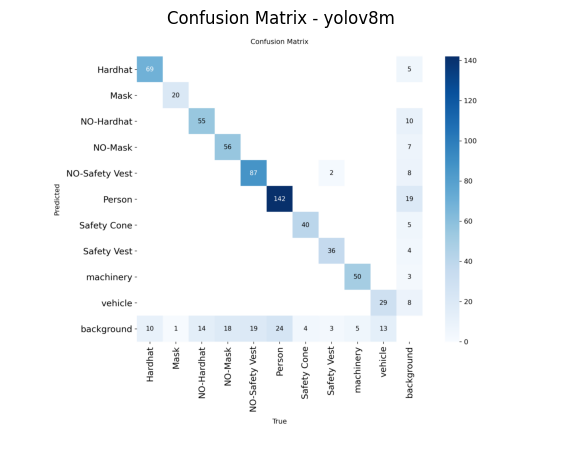

In [18]:
# Step 4.7: Show Confusion Matrix for each model
import matplotlib.pyplot as plt
from PIL import Image
import os

for model_name in ["yolov8n", "yolov8s", "yolov8m"]:
    cm_path = f"runs/detect/{model_name}/confusion_matrix.png"
    
    if os.path.exists(cm_path):
        print(f"\nConfusion Matrix — {model_name}")
        img = Image.open(cm_path)
        plt.figure(figsize=(7,7))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Confusion Matrix - {model_name}")
        plt.show()
    else:
        print(f"\nConfusion matrix not found for {model_name}. Expected at: {cm_path}")


## 4.8 Display PR Curve + F1 Curve (for each YOLO model)

In [19]:
# Step 4.8: Show PR Curve + F1 Curve for each model
import matplotlib.pyplot as plt
from PIL import Image
import os

plots = ["PR_curve.png", "F1_curve.png"]

for model_name in ["yolov8n", "yolov8s", "yolov8m"]:
    print(f"\n==============================")
    print(f"Curves for: {model_name}")
    print(f"==============================")
    
    for p in plots:
        plot_path = f"runs/detect/{model_name}/{p}"
        
        if os.path.exists(plot_path):
            img = Image.open(plot_path)
            plt.figure(figsize=(7,7))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"{p.replace('_',' ').replace('.png','')} - {model_name}")
            plt.show()
        else:
            print(f"Not found: {plot_path}")



Curves for: yolov8n
Not found: runs/detect/yolov8n/PR_curve.png
Not found: runs/detect/yolov8n/F1_curve.png

Curves for: yolov8s
Not found: runs/detect/yolov8s/PR_curve.png
Not found: runs/detect/yolov8s/F1_curve.png

Curves for: yolov8m
Not found: runs/detect/yolov8m/PR_curve.png
Not found: runs/detect/yolov8m/F1_curve.png


## 4.9 Create Academic Summary Table + Save as CSV

In [20]:
# Step 4.9: Build comparison table from results.csv and save it
import pandas as pd
import os

runs = ["yolov8n", "yolov8s", "yolov8m"]
rows = []

for r in runs:
    csv_path = f"runs/detect/{r}/results.csv"
    
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        last = df.tail(1).iloc[0]  # last epoch row
        
        rows.append({
            "Model": r,
            "mAP50": last.get("metrics/mAP50(B)", None),
            "mAP50-95": last.get("metrics/mAP50-95(B)", None),
            "Precision": last.get("metrics/precision(B)", None),
            "Recall": last.get("metrics/recall(B)", None),
            "BoxLoss": last.get("train/box_loss", None),
            "ClsLoss": last.get("train/cls_loss", None),
            "DflLoss": last.get("train/dfl_loss", None),
        })
    else:
        print(f"Missing results.csv for {r}: {csv_path}")

summary_df = pd.DataFrame(rows).sort_values(by="mAP50", ascending=False)
summary_df


,Model,mAP50,mAP50-95,Precision,Recall,BoxLoss,ClsLoss,DflLoss
2,yolov8m,0.87513,0.62234,0.91274,0.80654,0.50833,0.30843,0.92469
1,yolov8s,0.85576,0.57995,0.95396,0.76860,0.59855,0.38345,0.95051
0,yolov8n,0.79921,0.49934,0.88105,0.73119,0.78810,0.58208,1.05571


In [21]:
out_path = "/kaggle/working/comparison_results.csv"
summary_df.to_csv(out_path, index=False)
print("Saved:", out_path)


Saved: /kaggle/working/comparison_results.csv


### you can :
Increase epochs to 120

Increase imgsz to 896 or 960

Use yolov8l for final high-accuracy model

# STEP 5 —  Test Evaluation & Deployment Readiness

## 5.1 Select Best Model From Comparison Table

In [22]:
import pandas as pd

summary_df = pd.read_csv("/kaggle/working/comparison_results.csv")
summary_df = summary_df.sort_values("mAP50", ascending=False).reset_index(drop=True)

best_model = summary_df.loc[0, "Model"]

print("Best Model Selected:", best_model)
summary_df


Best Model Selected: yolov8m


,Model,mAP50,mAP50-95,Precision,Recall,BoxLoss,ClsLoss,DflLoss
0,yolov8m,0.87513,0.62234,0.91274,0.80654,0.50833,0.30843,0.92469
1,yolov8s,0.85576,0.57995,0.95396,0.76860,0.59855,0.38345,0.95051
2,yolov8n,0.79921,0.49934,0.88105,0.73119,0.78810,0.58208,1.05571


## 5.2 Load Best Model Weights

In [23]:
from ultralytics import YOLO

best_weights = f"runs/detect/{best_model}/weights/best.pt"
model = YOLO(best_weights)

print("Loaded Weights:", best_weights)


Loaded Weights: runs/detect/yolov8m/weights/best.pt


## 5.3 Final Evaluation on Test Set

In [24]:
metrics_test = model.val(data=DATA_YAML, split="test")

print("===== FINAL TEST METRICS =====")
print("mAP50:", metrics_test.box.map50)
print("mAP50-95:", metrics_test.box.map)
print("Precision:", metrics_test.box.mp)
print("Recall:", metrics_test.box.mr)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 2.7±0.2 ms, read: 5.0±1.7 MB/s, size: 40.8 KB)
val: Scanning /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/labels... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 202.7it/s 0.4s
WARNING ⚠️ val: Cache directory /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.7it/s 3.6s
                   all         82        760      0.943      0.768      0.839      0.591
               Hardhat         30        110      0.988      0.936      0.973      0.689
                  Mask         16         28      0.971       0.75      0.824      0.606
            NO-Hardhat         25         41   

## 5.4 Per-Class Performance Analysis

In [25]:
print("\n===== PER-CLASS mAP50 =====")

for i, class_name in enumerate(NAMES):
    print(f"{class_name:20s} : {metrics_test.box.maps[i]:.4f}")



===== PER-CLASS mAP50 =====
Hardhat              : 0.6895
Mask                 : 0.6064
NO-Hardhat           : 0.4554
NO-Mask              : 0.5256
NO-Safety Vest       : 0.6318
Person               : 0.6742
Safety Cone          : 0.2529
Safety Vest          : 0.7210
machinery            : 0.7448
vehicle              : 0.6126


# 5.5 Display Confusion Matrix

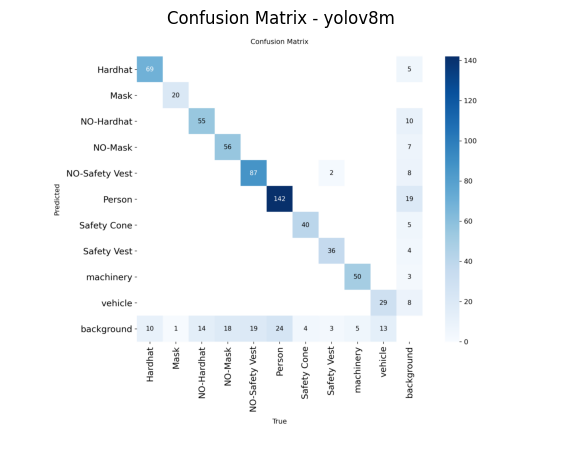

In [26]:
import matplotlib.pyplot as plt
from PIL import Image
import os

cm_path = f"runs/detect/{best_model}/confusion_matrix.png"

if os.path.exists(cm_path):
    img = Image.open(cm_path)
    plt.figure(figsize=(7,7))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Confusion Matrix - {best_model}")
    plt.show()
else:
    print("Confusion matrix not found.")


## 5.6 Inference Speed (Real-Time Feasibility Test)

In [27]:
import time
import glob

test_imgs = glob.glob(f"{DATASET_BASE}/test/images/*.*")[:50]

start = time.time()
model.predict(source=test_imgs, imgsz=960, conf=0.25)
end = time.time()

avg_time = (end - start) / len(test_imgs)
fps = 1 / avg_time

print("Average Inference Time per Image:", round(avg_time, 4), "seconds")
print("Approximate FPS:", round(fps, 2))



0: 960x960 1 Hardhat, 1 Person, 1 Safety Vest, 1 machinery, 55.7ms
1: 960x960 3 Hardhats, 3 NO-Masks, 3 NO-Safety Vests, 4 Persons, 55.7ms
2: 960x960 (no detections), 55.7ms
3: 960x960 4 Hardhats, 3 NO-Masks, 4 NO-Safety Vests, 3 Persons, 55.7ms
4: 960x960 1 Mask, 1 NO-Hardhat, 2 NO-Safety Vests, 1 Person, 55.7ms
5: 960x960 3 Persons, 7 machinerys, 19 vehicles, 55.7ms
6: 960x960 1 Hardhat, 1 NO-Mask, 1 NO-Safety Vest, 2 Persons, 55.7ms
7: 960x960 5 Hardhats, 1 NO-Hardhat, 5 NO-Safety Vests, 7 Persons, 1 Safety Vest, 55.7ms
8: 960x960 3 machinerys, 55.7ms
9: 960x960 2 NO-Hardhats, 2 NO-Masks, 2 NO-Safety Vests, 2 Persons, 2 machinerys, 55.7ms
10: 960x960 1 NO-Hardhat, 1 Person, 1 Safety Vest, 2 machinerys, 6 vehicles, 55.7ms
11: 960x960 2 Hardhats, 2 NO-Masks, 1 Person, 1 Safety Vest, 55.7ms
12: 960x960 1 NO-Safety Vest, 1 Person, 55.7ms
13: 960x960 3 Safety Cones, 2 vehicles, 55.7ms
14: 960x960 1 NO-Safety Vest, 3 Persons, 20 Safety Cones, 1 vehicle, 55.7ms
15: 960x960 1 NO-Mask, 1 NO

## 5.7 Generate Final Demo Predictions

In [28]:
model.predict(
    source=test_imgs[:20],
    conf=0.25,
    imgsz=960,
    save=True,
    name=f"{best_model}_FINAL_DEMO"
)

print("Demo predictions saved.")



0: 960x960 1 Hardhat, 1 Person, 1 Safety Vest, 1 machinery, 53.7ms
1: 960x960 3 Hardhats, 3 NO-Masks, 3 NO-Safety Vests, 4 Persons, 53.7ms
2: 960x960 (no detections), 53.7ms
3: 960x960 4 Hardhats, 3 NO-Masks, 4 NO-Safety Vests, 3 Persons, 53.7ms
4: 960x960 1 Mask, 1 NO-Hardhat, 2 NO-Safety Vests, 1 Person, 53.7ms
5: 960x960 3 Persons, 7 machinerys, 19 vehicles, 53.7ms
6: 960x960 1 Hardhat, 1 NO-Mask, 1 NO-Safety Vest, 2 Persons, 53.7ms
7: 960x960 5 Hardhats, 1 NO-Hardhat, 5 NO-Safety Vests, 7 Persons, 1 Safety Vest, 53.7ms
8: 960x960 3 machinerys, 53.7ms
9: 960x960 2 NO-Hardhats, 2 NO-Masks, 2 NO-Safety Vests, 2 Persons, 2 machinerys, 53.7ms
10: 960x960 1 NO-Hardhat, 1 Person, 1 Safety Vest, 2 machinerys, 6 vehicles, 53.7ms
11: 960x960 2 Hardhats, 2 NO-Masks, 1 Person, 1 Safety Vest, 53.7ms
12: 960x960 1 NO-Safety Vest, 1 Person, 53.7ms
13: 960x960 3 Safety Cones, 2 vehicles, 53.7ms
14: 960x960 1 NO-Safety Vest, 3 Persons, 20 Safety Cones, 1 vehicle, 53.7ms
15: 960x960 1 NO-Mask, 1 NO

## 5.8 Create Final Export Folder

In [29]:
import os
import shutil

final_dir = "/kaggle/working/final_outputs"
os.makedirs(final_dir, exist_ok=True)

# Save best weights
shutil.copy(best_weights, f"{final_dir}/best.pt")

# Save comparison table
shutil.copy("/kaggle/working/comparison_results.csv",
            f"{final_dir}/comparison_results.csv")

print("Final outputs saved at:", final_dir)


Final outputs saved at: /kaggle/working/final_outputs


## 5.9 Optional — Export ONNX (Deployment Ready)

In [30]:
model.export(format="onnx")


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/yolov8m/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 347ms
Prepared 2 packages in 2.93s
Installed 2 packages in 13ms
 + onnxruntime-gpu==1.24.1
 + onnxslim==0.1.85

requirements: AutoUpdate success ✅ 4.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 22...


/usr/local/lib/python3.12/dist-packages/torch/onnx/utils.py:1397: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.85...
ONNX: export success ✅ 7.7s, saved as 'runs/detect/yolov8m/weights/best.onnx' (98.8 MB)

Export complete (9.2s)
Results saved to /kaggle/working/runs/detect/yolov8m/weights
Predict:         yolo predict task=detect model=runs/detect/yolov8m/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/yolov8m/weights/best.onnx imgsz=640 data=/kaggle/working/data.yaml  
Visualize:       https://netron.app


'runs/detect/yolov8m/weights/best.onnx'